# 06 - Define the Commute Risk Metric

Now that we have generated school routes across South Yorkshire and merged them with the STATS19 collision dataset, we aim to identify the risk level of each route. However, defining what makes a route “dangerous” is not straightforward. For example, simply using the number of collisions or casualties would unfairly penalize longer routes, which naturally cover more area and have greater exposure.

Therefore, in this notebook, we explore multiple candidate approaches to fairly assess and compare the relative danger levels of routes, with a particular focus on avoiding arbitrary scoring systems.

In [111]:
# autoreload setup
%load_ext autoreload
%autoreload 2

# imports
import importlib
from util import commute_risk_metrics as crm
importlib.reload(crm)
import pandas as pd
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [112]:
df = pd.read_csv('../data/stats19_routes_combined.csv', low_memory=False)

In [115]:
# df = df.drop(columns='Unnamed: 0')
display(df)
counts = df["accident_index"].value_counts()
print(counts.unique())
average = counts.mean()
print(f"Average count per unique accident_index: {average:.2f}")
route_counts = df.groupby("accident_index")["route_id"].nunique().sort_values(ascending=False)
print(route_counts.head(10))



,Unnamed: 0,accident_index,accident_year,accident_reference,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,...,escooter_flag,dir_from_e,dir_from_n,dir_to_e,dir_to_n,driver_distance_banding,route_id,school_name,borough,length_km
0,0,2019140806065,2019,140806065,1,1,3,2,15,3,...,0,NaN,NaN,NaN,NaN,1,barnsley_college_6,Barnsley College,Barnsley,5.832
1,1,2019140806065,2019,140806065,1,1,3,2,15,3,...,0,NaN,NaN,NaN,NaN,1,barnsley_college_6,Barnsley College,Barnsley,5.832
2,2,2019140806065,2019,140806065,1,1,3,2,15,3,...,0,NaN,NaN,NaN,NaN,1,barnsley_college_6,Barnsley College,Barnsley,5.832
3,3,2019140806065,2019,140806065,1,1,3,2,15,3,...,0,NaN,NaN,NaN,NaN,1,barnsley_college_6,Barnsley College,Barnsley,5.832
4,4,2019140806065,2019,140806065,1,1,3,2,15,3,...,0,NaN,NaN,NaN,NaN,1,barnsley_college_7,Barnsley College,Barnsley,5.425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44477,44477,2023141392615,2023,141392615,2,1,1,1,14,3,...,1,NaN,NaN,NaN,NaN,1,utc_21,Utc,Doncaster,5.527
44478,44478,2023141392615,2023,141392615,2,1,1,1,14,3,...,1,NaN,NaN,NaN,NaN,1,utc_22,Utc,Doncaster,5.217
44479,44479,2023141392615,2023,141392615,2,1,1,1,14,3,...,1,NaN,NaN,NaN,NaN,1,utc_23,Utc,Doncaster,4.867
44480,44480,2023141392615,2023,141392615,2,1,1,1,14,3,...,1,NaN,NaN,NaN,NaN,1,xp_school_18,Xp School,Doncaster,6.262


[8092 3087 2430 1274 1056  936  882  816  704  650  540  512  448  432
  416  400  396  384  378  350  320  304  300  294  288  272  270  243
  224  216  208  192  189  180  176  171  164  162  160  150  144  128
  126  125  117  112  108  100   99   96   88   84   81   80   75   72
   68   64   63   56   54   52   50   48   45   44   40   36   32   31
   29   28   27   25   24   23   22   21   20   19   18   17   16   15
   14   13   12   11   10    9    8    7    6    5    4    3    2    1]
Average count per unique accident_index: 46.72
accident_index
2019140845361    48
2023141345983    41
2019140870377    36
2022141140809    36
2022141227589    31
2021141110516    29
2022141184745    28
2019140825685    27
2022141162596    26
2022141184455    26
Name: route_id, dtype: int64


## 1. Build Route-Level Base Metrics

- Total collision count  
- Total casualty count  
- Total severe injuries

These are useful for intuition but **biased toward longer or more-used routes**. Not used in final ranking, shown for reference only.





In [116]:
crm_table = crm.build_commute_risk_metrics(df, filter_col='accident_year', filter_values=[2019, 2020, 2021, 2022, 2023])
display(crm_table.head(2))

,route_id,school_name,borough,length_km,collision_count,casualty_count
0,barnsley_college_6,Barnsley College,Barnsley,5.832,5,9
1,barnsley_college_7,Barnsley College,Barnsley,5.425,4,6


## 2. Per-Kilometre Normalized Metrics

We calculate per-km values for the base metrics defined above. This adjustment accounts for variation in route lengths.

In [118]:
metric_cols = [
  "collision_count", 
  "casualty_count", 
] #  "avg_casualty_severity",  "serious_fatal_casualty_count"
crm_table = crm.add_normalised_metrics(crm_table, metric_cols)
display(crm_table.head(2))

,route_id,school_name,borough,length_km,collision_count,casualty_count,collision_count_per_km,casualty_count_per_km
0,barnsley_college_6,Barnsley College,Barnsley,5.832,5,9,0.857339,1.543210
1,barnsley_college_7,Barnsley College,Barnsley,5.425,4,6,0.737327,1.105991


## 3. Metrics based on Poisson Regression
We use Poisson regression to model expected values based on route length, then compute:
- risk_ratio : ratio of metric value to expected value if all routes were equally risky.
- excess_per_km : metric value - expected value

In [119]:
crm_table = crm.add_poisson_risk_metrics(crm_table, metric_cols)
display(crm_table.head(2))

,route_id,school_name,borough,length_km,collision_count,casualty_count,collision_count_per_km,casualty_count_per_km,poisson_risk_ratio_collision_count,poisson_excess_per_km_collision_count,poisson_risk_ratio_casualty_count,poisson_excess_per_km_casualty_count
0,barnsley_college_6,Barnsley College,Barnsley,5.832,5,9,0.857339,1.543210,1.861901,0.396875,2.032675,0.784008
1,barnsley_college_7,Barnsley College,Barnsley,5.425,4,6,0.737327,1.105991,1.601269,0.276863,1.456782,0.346789


## Scaling metric values for ranking and composite score
We will use minmax scaler to avoid biases in composite scores and further analyses.

In [120]:
from sklearn.preprocessing import MinMaxScaler

normalised_cols = [f"{col}_per_km" for col in metric_cols]
poisson_excess_cols = [f"poisson_excess_per_km_{col}" for col in metric_cols]

# Choose columns to scale
metrics = metric_cols + normalised_cols + poisson_excess_cols

scaler = MinMaxScaler()
crm_scaled = crm_table.copy()
crm_scaled[[f"{m}_scaled" for m in metrics]] = scaler.fit_transform(crm_scaled[metrics])
display(crm_scaled)


,route_id,school_name,borough,length_km,collision_count,casualty_count,collision_count_per_km,casualty_count_per_km,poisson_risk_ratio_collision_count,poisson_excess_per_km_collision_count,poisson_risk_ratio_casualty_count,poisson_excess_per_km_casualty_count,collision_count_scaled,casualty_count_scaled,collision_count_per_km_scaled,casualty_count_per_km_scaled,poisson_excess_per_km_collision_count_scaled,poisson_excess_per_km_casualty_count_scaled
0,barnsley_college_6,Barnsley College,Barnsley,5.832,5,9,0.857339,1.543210,1.861901,0.396875,2.032675,0.784008,0.363636,0.421053,0.181060,0.082352,0.181060,0.082352
1,barnsley_college_7,Barnsley College,Barnsley,5.425,4,6,0.737327,1.105991,1.601269,0.276863,1.456782,0.346789,0.272727,0.263158,0.154224,0.058239,0.154224,0.058239
2,barnsley_college_8,Barnsley College,Barnsley,5.530,5,7,0.904159,1.265823,1.963582,0.443695,1.667308,0.506621,0.363636,0.315789,0.191529,0.067054,0.191529,0.067054
3,holy_trinity_catholic_and_church_of_england_sc...,Holy Trinity Catholic And Church Of England Sc...,Barnsley,5.750,7,9,1.217391,1.565217,2.643835,0.756927,2.061663,0.806016,0.545455,0.421053,0.261569,0.083566,0.261569,0.083566
4,horizon_community_college_7,Horizon Community College,Barnsley,6.554,7,9,1.068050,1.373207,2.319507,0.607586,1.808752,0.614006,0.545455,0.421053,0.228176,0.072976,0.228176,0.072976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3023,bader_academy_21,Bader Academy,Doncaster,4.515,1,1,0.221484,0.221484,0.481001,-0.238980,0.291733,-0.537718,0.000000,0.000000,0.038879,0.009457,0.038879,0.009457
3024,kirk_balk_academy_18,Kirk Balk Academy,Barnsley,6.006,1,1,0.166500,0.166500,0.361592,-0.293964,0.219310,-0.592701,0.000000,0.000000,0.026584,0.006424,0.026584,0.006424
3025,springwell_alternative_academy_6,Springwell Alternative Academy,Barnsley,5.899,1,1,0.169520,0.169520,0.368151,-0.290944,0.223288,-0.589681,0.000000,0.000000,0.027260,0.006591,0.027260,0.006591
3026,springwell_alternative_academy_7,Springwell Alternative Academy,Barnsley,5.744,1,1,0.174095,0.174095,0.378085,-0.286369,0.229313,-0.585107,0.000000,0.000000,0.028283,0.006843,0.028283,0.006843


5. Add Composite Scores for Percentiles
Here, we create a composite rank each for the normalised metrics (normal counts) and Poisson metric (excess counts), and then create a meta composite percentile rank for both of these.

In [136]:
normalised_cols = [f"{col}_per_km" for col in metric_cols]
poisson_excess_cols = [f"poisson_excess_per_km_{col}" for col in metric_cols]
core_metrics = [f"{m}_scaled" for m in normalised_cols]
poisson_metrics = [f"{m}_scaled" for m in poisson_excess_cols]
crm_scaled = crm.calculate_composite_risk_score(crm_scaled, core_metrics, score_col="core_risk_score")
crm_scaled = crm.calculate_composite_risk_score(crm_scaled, poisson_metrics, score_col="poisson_excess_score")
meta_metrics = ["core_risk_score", "poisson_excess_score"]
crm_scaled = crm.calculate_composite_risk_score(crm_scaled, meta_metrics, score_col="final_composite_score")

# display(crm_scaled)
# print(crm_scaled.sort_values("final_composite_score", ascending=False))


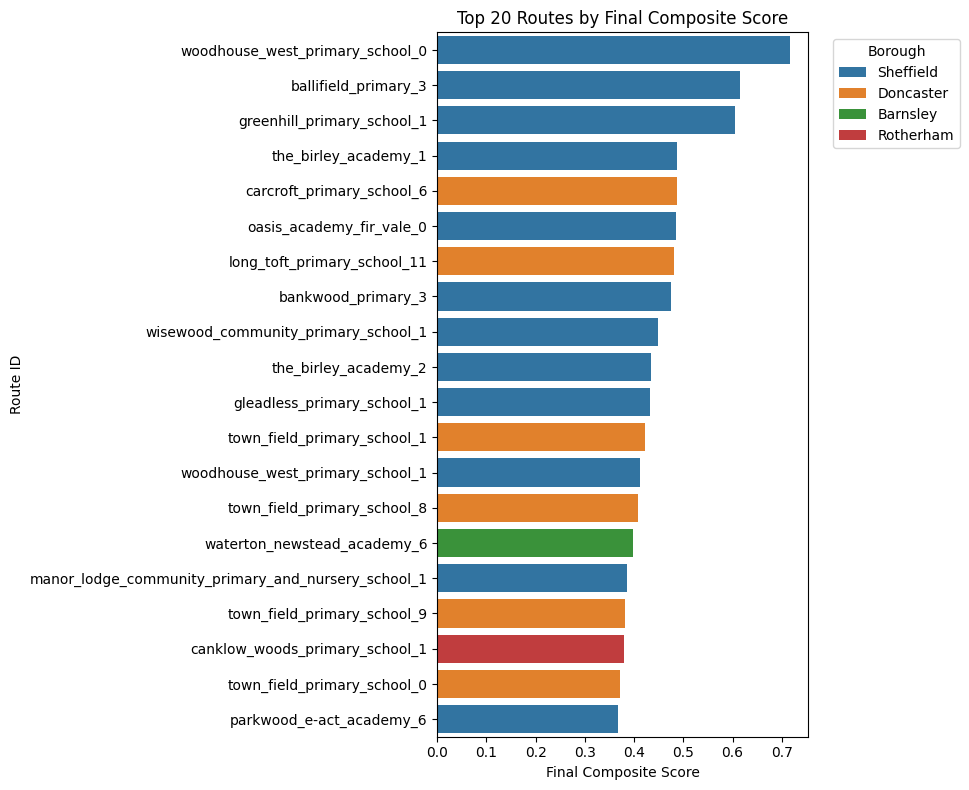

In [123]:
def plot_ranked_routes(df=crm_scaled, metric="final_composite_score", top_n=20):
    import matplotlib.pyplot as plt
    import seaborn as sns

    top_df = df.sort_values(metric, ascending=False).head(top_n)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=top_df, x=metric, y="route_id", hue="borough", dodge=False)
    plt.title(f"Top {top_n} Routes by {metric.replace('_', ' ').title()}")
    plt.xlabel(metric.replace('_', ' ').title())
    plt.ylabel("Route ID")
    plt.legend(title="Borough", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_ranked_routes()

In [125]:
def display_top_routes_table(
    df,
    metric="final_composite_score",
    top_n=20,
    group_cols=["borough", "school_name"],
    show_metrics=None
):
    """
    Displays a ranked table of top N routes with their metrics, grouped by borough and school.

    Parameters:
    - df: DataFrame containing route metrics
    - metric: column to rank by
    - top_n: number of top routes to show
    - group_cols: columns to include before metrics (e.g., borough, school_name)
    - show_metrics: list of metrics to display; if None, show all scaled metrics
    """
    import pandas as pd
    from IPython.display import display

    top_df = df.sort_values(metric, ascending=False).head(top_n).copy()
    
    if show_metrics is None:
        show_metrics = [col for col in df.columns]
    
    cols_to_display = group_cols + ["route_id"] + show_metrics
    display(top_df[cols_to_display].reset_index(drop=True))

display_top_routes_table(crm_scaled, metric='casualty_count_per_km', top_n=10)

,borough,school_name,route_id,route_id,school_name,borough,length_km,collision_count,casualty_count,collision_count_per_km,...,poisson_excess_per_km_casualty_count,collision_count_scaled,casualty_count_scaled,collision_count_per_km_scaled,casualty_count_per_km_scaled,poisson_excess_per_km_collision_count_scaled,poisson_excess_per_km_casualty_count_scaled,core_risk_score,poisson_excess_score,final_composite_score
0,Sheffield,Ballifield Primary,ballifield_primary_3,ballifield_primary_3,Ballifield Primary,Sheffield,0.935,1,17,1.069519,...,17.422617,0.000000,0.842105,0.228504,1.000000,0.228504,1.000000,0.614252,0.614252,0.614252
1,Sheffield,Greenhill Primary School,greenhill_primary_school_1,greenhill_primary_school_1,Greenhill Primary School,Sheffield,1.045,3,11,2.870813,...,9.767114,0.181818,0.526316,0.631284,0.577786,0.631284,0.577786,0.604535,0.604535,0.604535
2,Sheffield,Athelstan Primary,athelstan_primary_2,athelstan_primary_2,Athelstan Primary,Sheffield,1.751,1,17,0.571102,...,8.949536,0.000000,0.842105,0.117056,0.532695,0.117056,0.532695,0.324875,0.324875,0.324875
3,Sheffield,Woodhouse West Primary School,woodhouse_west_primary_school_0,woodhouse_west_primary_school_0,Woodhouse West Primary School,Sheffield,0.885,4,7,4.519774,...,7.150403,0.272727,0.315789,1.000000,0.433470,1.000000,0.433470,0.716735,0.716735,0.716735
4,Sheffield,Bankwood Primary,bankwood_primary_3,bankwood_primary_3,Bankwood Primary,Sheffield,0.404,1,3,2.475248,...,6.666541,0.000000,0.105263,0.542833,0.406784,0.542833,0.406784,0.474808,0.474808,0.474808
5,Sheffield,Manor Lodge Community Primary And Nursery School,manor_lodge_community_primary_and_nursery_scho...,manor_lodge_community_primary_and_nursery_scho...,Manor Lodge Community Primary And Nursery School,Sheffield,0.565,1,4,1.769912,...,6.320445,0.000000,0.157895,0.385116,0.387696,0.385116,0.387696,0.386406,0.386406,0.386406
6,Sheffield,Woodhouse West Primary School,woodhouse_west_primary_school_1,woodhouse_west_primary_school_1,Woodhouse West Primary School,Sheffield,1.393,3,9,2.153625,...,5.701674,0.181818,0.421053,0.470916,0.353570,0.470916,0.353570,0.412243,0.412243,0.412243
7,Sheffield,Woodhouse West Primary School,woodhouse_west_primary_school_4,woodhouse_west_primary_school_4,Woodhouse West Primary School,Sheffield,0.635,1,4,1.574803,...,5.540011,0.000000,0.157895,0.341489,0.344654,0.341489,0.344654,0.343071,0.343071,0.343071
8,Rotherham,Waverley Junior Academy,waverley_junior_academy_1,waverley_junior_academy_1,Waverley Junior Academy,Rotherham,2.817,1,17,0.354988,...,5.275587,0.000000,0.842105,0.068731,0.330071,0.068731,0.330071,0.199401,0.199401,0.199401
9,Rotherham,Canklow Woods Primary School,canklow_woods_primary_school_1,canklow_woods_primary_school_1,Canklow Woods Primary School,Rotherham,2.521,5,15,1.983340,...,5.190818,0.363636,0.736842,0.432840,0.325395,0.432840,0.325395,0.379118,0.379118,0.379118


In [134]:
def print_rankings_by_borough(
    df,
    metric="final_composite_score_scaled",
    top_n=5,
    show_metrics=None
):
    """
    Prints a ranking table for each borough, showing top N routes with selected metrics.
    
    Parameters:
    - df: DataFrame with route metrics
    - metric: column to sort by (composite score or base risk metric)
    - top_n: number of top routes per borough
    - show_metrics: optional list of additional metric columns to display;
                    if None, auto-select all *_scaled columns except the base metric
    """
    from IPython.display import display
    boroughs = df["borough"].unique()
    
    if show_metrics is None:
        show_metrics = [
            col for col in df.columns 
        ]

    for borough in sorted(boroughs):
        print(f"\n🔹 Top {top_n} Routes in **{borough}** by {metric.replace('_', ' ').title()}:")
        borough_df = df[df["borough"] == borough].copy()
        top_df = borough_df.sort_values(metric, ascending=False).head(top_n)
        display(top_df.reset_index(drop=True))

print_rankings_by_borough(crm_scaled, metric='poisson_excess_per_km_collision_count', top_n = 10)
print(crm_scaled[crm_scaled['school_name']=="Meadstead Primary Academy"])


🔹 Top 10 Routes in **Barnsley** by Poisson Excess Per Km Collision Count:


,route_id,school_name,borough,length_km,collision_count,casualty_count,collision_count_per_km,casualty_count_per_km,poisson_risk_ratio_collision_count,poisson_excess_per_km_collision_count,...,poisson_excess_per_km_casualty_count,collision_count_scaled,casualty_count_scaled,collision_count_per_km_scaled,casualty_count_per_km_scaled,poisson_excess_per_km_collision_count_scaled,poisson_excess_per_km_casualty_count_scaled,core_risk_score,poisson_excess_score,final_composite_score
0,waterton_newstead_academy_6,Waterton Newstead Academy,Barnsley,3.442,9,14,2.614759,4.067403,5.678528,2.154295,...,3.308201,0.727273,0.684211,0.574028,0.221566,0.574028,0.221566,0.397797,0.397797,0.397797
1,royston_st_john_baptist_ce_primary_school_3,Royston St John Baptist Ce Primary School,Barnsley,3.222,6,11,1.862197,3.414029,4.044174,1.401733,...,2.654827,0.454545,0.526316,0.405752,0.185531,0.405752,0.185531,0.295641,0.295641,0.295641
2,parkside_primary_academy_4,Parkside Primary Academy,Barnsley,2.715,5,8,1.841621,2.946593,3.999487,1.381156,...,2.187392,0.363636,0.368421,0.401150,0.159751,0.401150,0.159751,0.280451,0.280451,0.280451
3,waterton_newstead_academy_5,Waterton Newstead Academy,Barnsley,4.298,7,10,1.628664,2.326664,3.537006,1.168200,...,1.567462,0.545455,0.473684,0.353532,0.125561,0.353532,0.125561,0.239547,0.239547,0.239547
4,waterton_newstead_academy_6,Waterton Newstead Academy,Barnsley,5.754,9,14,1.564129,2.433090,3.396853,1.103665,...,1.673889,0.727273,0.684211,0.339102,0.131431,0.339102,0.131431,0.235266,0.235266,0.235266
5,outwood_primary_academy_darfield_4,Outwood Primary Academy Darfield,Barnsley,2.691,4,4,1.486436,1.486436,3.228126,1.025972,...,0.727235,0.272727,0.157895,0.321729,0.079221,0.321729,0.079221,0.200475,0.200475,0.200475
6,carlton_primary_academy_9,Carlton Primary Academy,Barnsley,2.700,4,7,1.481481,2.592593,3.217365,1.021017,...,1.833391,0.272727,0.315789,0.320621,0.140228,0.320621,0.140228,0.230425,0.230425,0.230425
7,summerfields_primary_academy_5,Summerfields Primary Academy,Barnsley,2.737,4,7,1.461454,2.557545,3.173871,1.000990,...,1.798343,0.272727,0.315789,0.316143,0.138295,0.316143,0.138295,0.227219,0.227219,0.227219
8,horizon_community_college_8,Horizon Community College,Barnsley,5.541,8,10,1.443783,1.804728,3.135494,0.983319,...,1.045527,0.636364,0.473684,0.312192,0.096776,0.312192,0.096776,0.204484,0.204484,0.204484
9,outwood_academy_shafton_3,Outwood Academy Shafton,Barnsley,5.684,8,12,1.407460,2.111189,3.056610,0.946995,...,1.351988,0.636364,0.578947,0.304070,0.113677,0.304070,0.113677,0.208874,0.208874,0.208874



🔹 Top 10 Routes in **Doncaster** by Poisson Excess Per Km Collision Count:


,route_id,school_name,borough,length_km,collision_count,casualty_count,collision_count_per_km,casualty_count_per_km,poisson_risk_ratio_collision_count,poisson_excess_per_km_collision_count,...,poisson_excess_per_km_casualty_count,collision_count_scaled,casualty_count_scaled,collision_count_per_km_scaled,casualty_count_per_km_scaled,poisson_excess_per_km_collision_count_scaled,poisson_excess_per_km_casualty_count_scaled,core_risk_score,poisson_excess_score,final_composite_score
0,long_toft_primary_school_11,Long Toft Primary School,Doncaster,0.572,2,2,3.496503,3.496503,7.593432,3.036039,...,2.737302,0.090909,0.052632,0.771191,0.190080,0.771191,0.190080,0.480636,0.480636,0.480636
1,carcroft_primary_school_6,Carcroft Primary School,Doncaster,1.353,4,8,2.956393,5.912786,6.420463,2.495929,...,5.153585,0.272727,0.368421,0.650420,0.323342,0.650420,0.323342,0.486881,0.486881,0.486881
2,town_field_primary_school_8,Town Field Primary School,Doncaster,1.481,4,6,2.700878,4.051317,5.865554,2.240414,...,3.292115,0.272727,0.263158,0.593285,0.220679,0.593285,0.220679,0.406982,0.406982,0.406982
3,town_field_primary_school_1,Town Field Primary School,Doncaster,2.723,7,14,2.570694,5.141388,5.582832,2.110230,...,4.382187,0.545455,0.684211,0.564175,0.280798,0.564175,0.280798,0.422487,0.422487,0.422487
4,town_field_primary_school_9,Town Field Primary School,Doncaster,2.580,6,12,2.325581,4.651163,5.050515,1.865117,...,3.891961,0.454545,0.578947,0.509367,0.253761,0.509367,0.253761,0.381564,0.381564,0.381564
5,town_field_primary_school_0,Town Field Primary School,Doncaster,2.646,6,12,2.267574,4.535147,4.924539,1.807110,...,3.775946,0.454545,0.578947,0.496396,0.247363,0.496396,0.247363,0.371879,0.371879,0.371879
6,armthorpe_academy_4,Armthorpe Academy,Doncaster,2.295,5,9,2.178649,3.921569,4.731419,1.718185,...,3.162367,0.363636,0.421053,0.476512,0.213523,0.476512,0.213523,0.345017,0.345017,0.345017
7,armthorpe_academy_26,Armthorpe Academy,Doncaster,5.616,12,17,2.136752,3.027066,4.640431,1.676288,...,2.267864,1.000000,0.842105,0.467143,0.164190,0.467143,0.164190,0.315667,0.315667,0.315667
8,armthorpe_academy_0,Armthorpe Academy,Doncaster,5.725,12,17,2.096070,2.969432,4.552080,1.635606,...,2.210231,1.000000,0.842105,0.458047,0.161011,0.458047,0.161011,0.309529,0.309529,0.309529
9,owston_park_primary_school_5,Owston Park Primary School,Doncaster,2.459,5,10,2.033347,4.066694,4.415863,1.572883,...,3.307492,0.363636,0.473684,0.444021,0.221527,0.444021,0.221527,0.332774,0.332774,0.332774



🔹 Top 10 Routes in **Rotherham** by Poisson Excess Per Km Collision Count:


,route_id,school_name,borough,length_km,collision_count,casualty_count,collision_count_per_km,casualty_count_per_km,poisson_risk_ratio_collision_count,poisson_excess_per_km_collision_count,...,poisson_excess_per_km_casualty_count,collision_count_scaled,casualty_count_scaled,collision_count_per_km_scaled,casualty_count_per_km_scaled,poisson_excess_per_km_collision_count_scaled,poisson_excess_per_km_casualty_count_scaled,core_risk_score,poisson_excess_score,final_composite_score
0,thurcroft_junior_academy_9,Thurcroft Junior Academy,Rotherham,1.962,5,5,2.548420,2.548420,5.534458,2.087956,...,1.789218,0.363636,0.210526,0.559195,0.137791,0.559195,0.137791,0.348493,0.348493,0.348493
1,thurcroft_junior_academy_10,Thurcroft Junior Academy,Rotherham,2.436,5,5,2.052545,2.052545,4.457556,1.592081,...,1.293344,0.363636,0.210526,0.448314,0.110443,0.448314,0.110443,0.279379,0.279379,0.279379
2,canklow_woods_primary_school_1,Canklow Woods Primary School,Rotherham,2.521,5,15,1.983340,5.950020,4.307262,1.522876,...,5.190818,0.363636,0.736842,0.432840,0.325395,0.432840,0.325395,0.379118,0.379118,0.379118
3,brinsworth_manor_infant_school_7,Brinsworth Manor Infant School,Rotherham,2.731,5,15,1.830831,5.492494,3.976056,1.370367,...,4.733292,0.363636,0.736842,0.398738,0.300162,0.398738,0.300162,0.349450,0.349450,0.349450
4,ferham_primary_school_5,Ferham Primary School,Rotherham,2.834,5,7,1.764291,2.470007,3.831548,1.303827,...,1.710806,0.363636,0.315789,0.383859,0.133467,0.383859,0.133467,0.258663,0.258663,0.258663
5,brinsworth_whitehill_primary_school_6,Brinsworth Whitehill Primary School,Rotherham,2.929,5,15,1.707067,5.121202,3.707275,1.246603,...,4.362000,0.363636,0.736842,0.371064,0.279685,0.371064,0.279685,0.325374,0.325374,0.325374
6,canklow_woods_primary_school_2,Canklow Woods Primary School,Rotherham,2.528,4,14,1.582278,5.537975,3.436268,1.121814,...,4.778773,0.272727,0.684211,0.343160,0.302670,0.343160,0.302670,0.322915,0.322915,0.322915
7,brinsworth_manor_junior_school_7,Brinsworth Manor Junior School,Rotherham,3.162,5,15,1.581278,4.743833,3.434095,1.120813,...,3.984632,0.363636,0.736842,0.342936,0.258872,0.342936,0.258872,0.300904,0.300904,0.300904
8,ferham_primary_school_6,Ferham Primary School,Rotherham,2.798,4,6,1.429593,2.144389,3.104677,0.969128,...,1.385187,0.272727,0.263158,0.309019,0.115508,0.309019,0.115508,0.212264,0.212264,0.212264
9,coleridge_primary_school_0,Coleridge Primary School,Rotherham,2.815,4,4,1.420959,1.420959,3.085928,0.960495,...,0.661758,0.272727,0.157895,0.307088,0.075610,0.307088,0.075610,0.191349,0.191349,0.191349



🔹 Top 10 Routes in **Sheffield** by Poisson Excess Per Km Collision Count:


,route_id,school_name,borough,length_km,collision_count,casualty_count,collision_count_per_km,casualty_count_per_km,poisson_risk_ratio_collision_count,poisson_excess_per_km_collision_count,...,poisson_excess_per_km_casualty_count,collision_count_scaled,casualty_count_scaled,collision_count_per_km_scaled,casualty_count_per_km_scaled,poisson_excess_per_km_collision_count_scaled,poisson_excess_per_km_casualty_count_scaled,core_risk_score,poisson_excess_score,final_composite_score
0,woodhouse_west_primary_school_0,Woodhouse West Primary School,Sheffield,0.885,4,7,4.519774,7.909605,9.815690,4.059310,...,7.150403,0.272727,0.315789,1.000000,0.433470,1.000000,0.433470,0.716735,0.716735,0.716735
1,oasis_academy_fir_vale_0,Oasis Academy Fir Vale,Sheffield,0.566,2,2,3.533569,3.533569,7.673928,3.073105,...,2.774367,0.090909,0.052632,0.779479,0.192124,0.779479,0.192124,0.485802,0.485802,0.485802
2,the_birley_academy_1,The Birley Academy,Sheffield,2.142,7,10,3.267974,4.668534,7.097129,2.807510,...,3.909333,0.545455,0.473684,0.720091,0.254719,0.720091,0.254719,0.487405,0.487405,0.487405
3,the_birley_academy_2,The Birley Academy,Sheffield,2.401,7,10,2.915452,4.164931,6.331550,2.454988,...,3.405730,0.545455,0.473684,0.641265,0.226945,0.641265,0.226945,0.434105,0.434105,0.434105
4,greenhill_primary_school_1,Greenhill Primary School,Sheffield,1.045,3,11,2.870813,10.526316,6.234607,2.410349,...,9.767114,0.181818,0.526316,0.631284,0.577786,0.631284,0.577786,0.604535,0.604535,0.604535
5,gleadless_primary_school_1,Gleadless Primary School,Sheffield,0.698,2,3,2.865330,4.297994,6.222698,2.404865,...,3.538793,0.090909,0.105263,0.630057,0.234283,0.630057,0.234283,0.432170,0.432170,0.432170
6,wisewood_community_primary_school_1,Wisewood Community Primary School,Sheffield,0.733,2,4,2.728513,5.457026,5.925570,2.268049,...,4.697824,0.090909,0.157895,0.599464,0.298206,0.599464,0.298206,0.448835,0.448835,0.448835
7,meadowhead_school_academy_10,Meadowhead School Academy,Sheffield,1.122,3,3,2.673797,2.673797,5.806742,2.213333,...,1.914595,0.181818,0.105263,0.587230,0.144706,0.587230,0.144706,0.365968,0.365968,0.365968
8,the_birley_academy_3,The Birley Academy,Sheffield,1.596,4,4,2.506266,2.506266,5.442911,2.045801,...,1.747064,0.272727,0.157895,0.549769,0.135467,0.549769,0.135467,0.342618,0.342618,0.342618
9,arbourthorne_community_primary_2,Arbourthorne Community Primary,Sheffield,0.799,2,2,2.503129,2.503129,5.436099,2.042665,...,1.743927,0.090909,0.052632,0.549067,0.135294,0.549067,0.135294,0.342180,0.342180,0.342180


                          route_id                school_name   borough  \
1641   meadstead_primary_academy_5  Meadstead Primary Academy  Barnsley   
1907   meadstead_primary_academy_3  Meadstead Primary Academy  Barnsley   
1908   meadstead_primary_academy_4  Meadstead Primary Academy  Barnsley   
2645   meadstead_primary_academy_0  Meadstead Primary Academy  Barnsley   
2646   meadstead_primary_academy_1  Meadstead Primary Academy  Barnsley   
2647  meadstead_primary_academy_11  Meadstead Primary Academy  Barnsley   
2744   meadstead_primary_academy_6  Meadstead Primary Academy  Barnsley   
2745   meadstead_primary_academy_7  Meadstead Primary Academy  Barnsley   

      length_km  collision_count  casualty_count  collision_count_per_km  \
1641      3.259                4               7                1.227370   
1907      3.660                2               2                0.546448   
1908      3.287                2               2                0.608458   
2645      2.872     

In [63]:
# crm_table.shape
# crm_table.columns
crm_table.to_csv('../data/routes/commute_risk_metrics_table.csv', index=False)

We see that the baseline is ~6 collisions per km. It is what is expected collision density per km if all routes had the same risk level. Now, we can visualise how the actual collisions look compared to baseline for each route.

##### Plotting Residual Risk

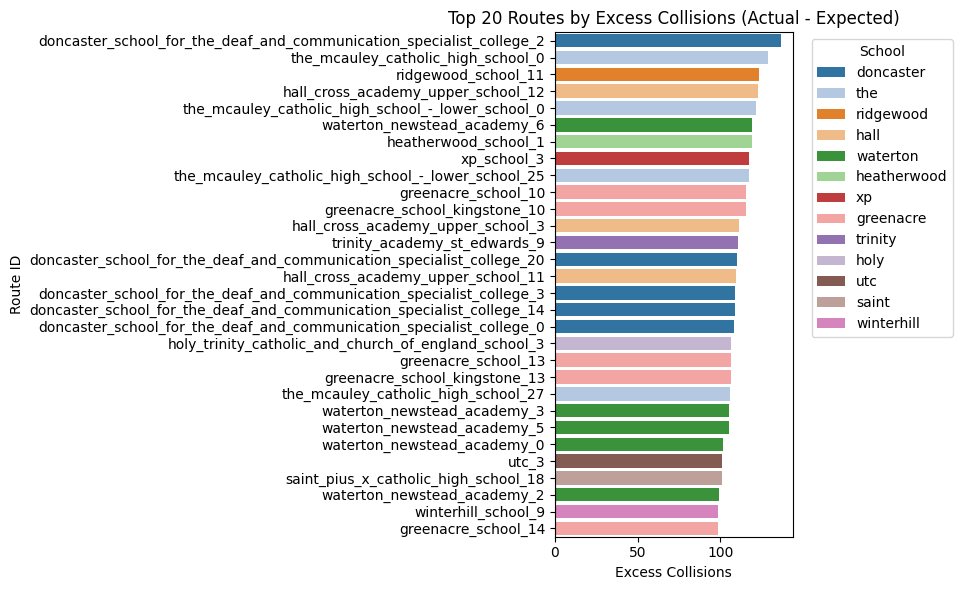

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Extract school name from route_id prefix
# df_model["school_name"] = df_model["route_id"].str.extract(r"(^[^_]+)")

# # Calculate residuals
# df_model["residual"] = df_model["collisions"] - df_model["expected"]

# # Select top 20 by excess collisions
# top_residuals = df_model.sort_values("residual", ascending=False).head(30)

# # Color by school
# school_palette = dict(zip(
#     top_residuals["school_name"].unique(),
#     sns.color_palette("tab20", n_colors=top_residuals["school_name"].nunique())
# ))

# plt.figure(figsize=(10, 6))
# sns.barplot(
#     data=top_residuals,
#     x="residual",
#     y="route_id",
#     hue="school_name",
#     dodge=False,
#     palette=school_palette
# )

# plt.axvline(0, color="black", linestyle="--")
# plt.title("Top 20 Routes by Excess Collisions (Actual - Expected)")
# plt.xlabel("Excess Collisions")
# plt.ylabel("Route ID")
# plt.legend(title="School", bbox_to_anchor=(1.05, 1), loc="upper left")
# plt.tight_layout()
# plt.show()



this is interesting, also checked out google maps for doncaster school for the deaf, and its right next to a big highway roundabout.

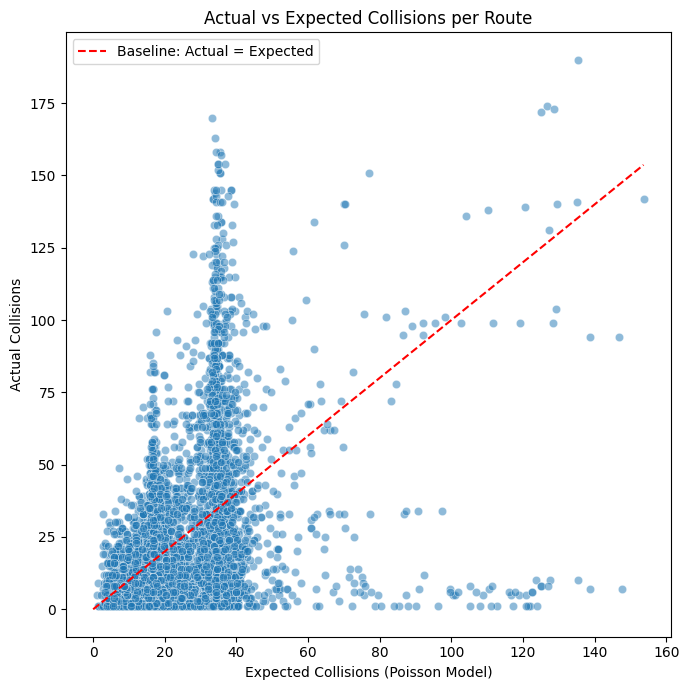

In [ ]:
# plt.figure(figsize=(7, 7))
# sns.scatterplot(data=df_model, x="expected", y="collisions", alpha=0.5)
# plt.plot([0, df_model["expected"].max()], [0, df_model["expected"].max()], color="red", linestyle="--", label="Baseline: Actual = Expected")
# plt.xlabel("Expected Collisions (Poisson Model)")
# plt.ylabel("Actual Collisions")
# plt.title("Actual vs Expected Collisions per Route")
# # plt.xscale("log")
# # plt.yscale("log")
# plt.legend()
# plt.tight_layout()
# plt.show()


<Axes: xlabel='expected', ylabel='collisions'>

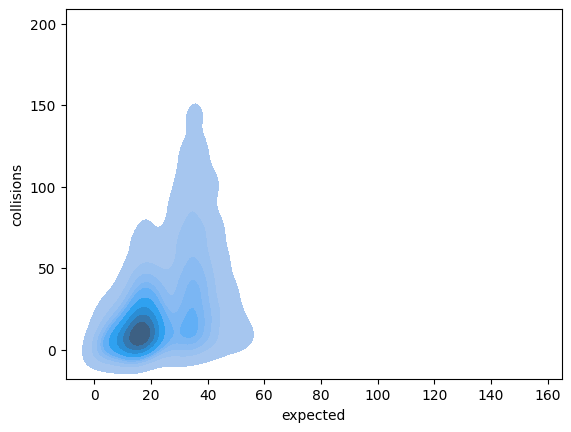

In [ ]:
# sns.kdeplot(data=df_model, x="expected", y="collisions", fill=True, thresh=0.05)

### 1.6. Implementing Machine Learning for Classfication of Routes into Risk level groups

In [138]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Select features for clustering
features = [
    'length_km',
    'collision_count',
    'casualty_count',
    'collision_count_per_km',
    'casualty_count_per_km',
    'poisson_risk_ratio_collision_count'
]

# Create feature DataFrame
X = df[features].copy()

# Handle any missing values
X = X.fillna(0)

# Apply scaling to normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=df.index)

In [140]:
# K-Means Clustering
kmeans = KMeans(n_clusters=5, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# DBSCAN (Density-Based Spatial Clustering)
dbscan = DBSCAN(eps=1.0, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

# Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering
hierarchical = AgglomerativeClustering(n_clusters=5)
df['hierarchical_cluster'] = hierarchical.fit_predict(X_scaled)

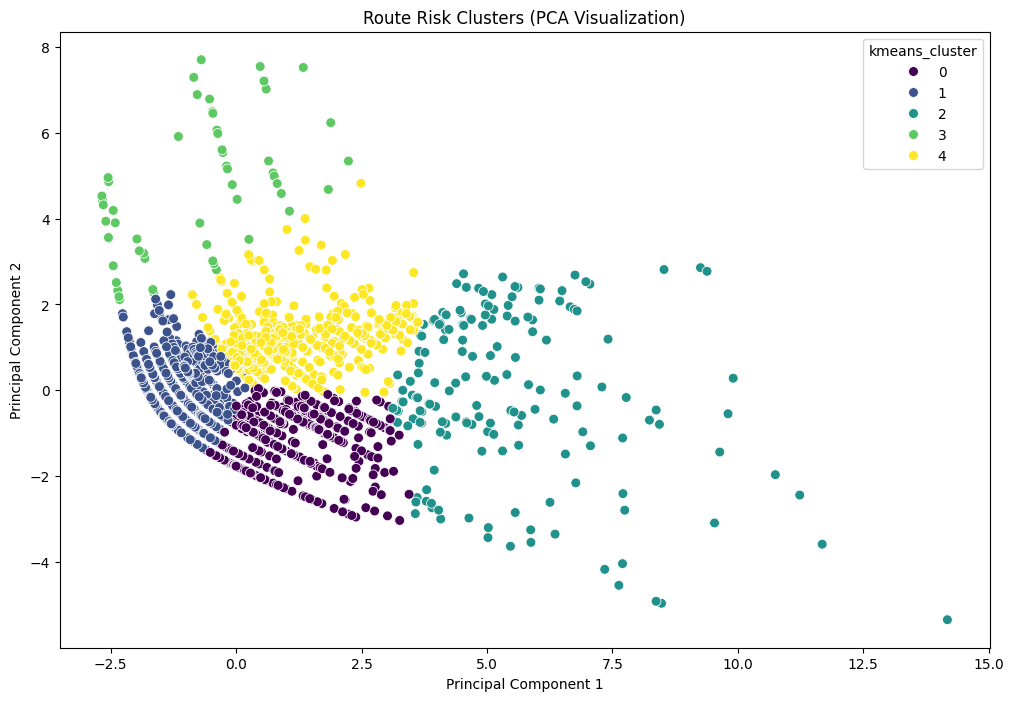

Cluster Statistics:
                 length_km  collision_count  casualty_count  \
kmeans_cluster                                               
2                3.563543         5.251429        9.331429   
0                2.362915         1.899489        3.064736   
4                6.067065         3.801852        6.192593   
1                4.367864         1.185363        1.893221   
3               16.705407         3.016949        6.067797   

                collision_count_per_km  casualty_count_per_km  \
kmeans_cluster                                                  
2                             1.600506               3.148857   
0                             0.826338               1.326479   
4                             0.645516               1.048291   
1                             0.300324               0.471804   
3                             0.186918               0.371425   

                poisson_risk_ratio_collision_count  
kmeans_cluster                     

In [147]:
# Apply PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]

# Plot clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x='pca_1', y='pca_2', hue='kmeans_cluster', data=df, palette='viridis', s=50)
plt.title('Route Risk Clusters (PCA Visualization)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.savefig('route_risk_clusters.png')
plt.show()

# Analyze cluster characteristics
# Sort clusters from highest to lowest average casualty rate
cluster_stats = df.groupby('kmeans_cluster')[features].mean().sort_values('casualty_count_per_km', ascending=False)
print("Cluster Statistics:\n", cluster_stats)

# Map clusters to readable risk categories
ranked_clusters = cluster_stats.index.tolist()

risk_mapping = {
    ranked_clusters[0]: "Very High Risk",
    ranked_clusters[1]: "High Risk",
    ranked_clusters[2]: "Moderate Risk",
    ranked_clusters[3]: "Low Risk",
    ranked_clusters[4]: "Minimal Risk"
}

df["risk_category"] = df["kmeans_cluster"].map(risk_mapping)


In [142]:
# Determine which cluster represents the highest risk
highest_risk_cluster = cluster_stats.index[0]

# Create risk categories based on clusters
risk_mapping = {
    highest_risk_cluster: 'Very High Risk',
    # Map other clusters based on their statistics
}

# Map clusters to risk categories
df['risk_category'] = df['kmeans_cluster'].map(risk_mapping)

# Get the top 20 highest risk routes for manual review
high_risk_routes = df[df['kmeans_cluster'] == highest_risk_cluster].sort_values(
    by=['casualty_count_per_km', 'collision_count_per_km'], 
    ascending=False
).head(20)

print("\nTop 20 Highest Risk Routes for Manual Review:")
print(high_risk_routes[['route_id', 'school_name', 'length_km', 
                       'collision_count', 'casualty_count', 
                       'collision_count_per_km', 'casualty_count_per_km']])


Top 20 Highest Risk Routes for Manual Review:
                                               route_id  \
1279                               ballifield_primary_3   
351                          greenhill_primary_school_1   
1277                                athelstan_primary_2   
2137                    woodhouse_west_primary_school_0   
1067                                 bankwood_primary_3   
2107  manor_lodge_community_primary_and_nursery_scho...   
2138                    woodhouse_west_primary_school_1   
1253                    woodhouse_west_primary_school_4   
1275                          waverley_junior_academy_1   
747                      canklow_woods_primary_school_1   
103                           carcroft_primary_school_6   
1278                               ballifield_primary_2   
1280       handsworth_grange_community_sports_college_6   
748                      canklow_woods_primary_school_2   
737                    brinsworth_manor_infant_school_7   
1612     

In [143]:
# Isolation Forest for anomaly detection
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = iso_forest.fit_predict(X_scaled)
df['is_anomaly'] = df['anomaly'] == -1  # -1 indicates anomaly

# Get anomalous routes
anomalous_routes = df[df['is_anomaly']].sort_values(
    by=['casualty_count_per_km', 'collision_count_per_km'], 
    ascending=False
)

print("\nAnomalous High-Risk Routes:")
print(anomalous_routes[['route_id', 'school_name', 'length_km', 
                       'collision_count', 'casualty_count', 
                       'collision_count_per_km', 'casualty_count_per_km']])


Anomalous High-Risk Routes:
                             route_id                    school_name  \
1279             ballifield_primary_3             Ballifield Primary   
351        greenhill_primary_school_1       Greenhill Primary School   
1277              athelstan_primary_2              Athelstan Primary   
2137  woodhouse_west_primary_school_0  Woodhouse West Primary School   
1067               bankwood_primary_3               Bankwood Primary   
...                               ...                            ...   
1714      stocksbridge_high_school_26       Stocksbridge High School   
1710      stocksbridge_high_school_22       Stocksbridge High School   
1713      stocksbridge_high_school_25       Stocksbridge High School   
1711      stocksbridge_high_school_23       Stocksbridge High School   
1712      stocksbridge_high_school_24       Stocksbridge High School   

      length_km  collision_count  casualty_count  collision_count_per_km  \
1279      0.935               

In [145]:
# Combine clustering and anomaly detection for final classification
def assign_risk_level(row):
    if row['is_anomaly']:
        return 'Critical Risk'
    elif row['kmeans_cluster'] == highest_risk_cluster:
        return 'Very High Risk'
    # Add more conditions based on your clusters
    else:
        return 'Normal Risk'

df['final_risk_level'] = df.apply(assign_risk_level, axis=1)

# Final list of routes for manual review
final_review_routes = df[df['final_risk_level'].isin(['Critical Risk', 'Very High Risk'])].sort_values(
    by=['final_risk_level', 'casualty_count_per_km'], 
    ascending=[False, False]
)

print("\nFinal Routes for Manual Review:")
display(final_review_routes[['route_id', 'school_name', 'length_km', 
                         'collision_count', 'casualty_count', 
                         'final_risk_level']].head(30))


Final Routes for Manual Review:


,route_id,school_name,length_km,collision_count,casualty_count,final_risk_level
734,brinsworth_howarth_primary_school_7,Brinsworth Howarth Primary School,2.117,2,9,Very High Risk
1520,aston_hall_junior_and_infant_school_5,Aston Hall Junior And Infant School,1.474,2,6,Very High Risk
744,brinsworth_whitehill_primary_school_5,Brinsworth Whitehill Primary School,2.686,3,10,Very High Risk
750,catcliffe_primary_school_6,Catcliffe Primary School,2.912,3,10,Very High Risk
742,brinsworth_manor_junior_school_8,Brinsworth Manor Junior School,2.928,3,10,Very High Risk
213,park_primary_school_0,Park Primary School,2.682,4,9,Very High Risk
735,brinsworth_manor_infant_school_5,Brinsworth Manor Infant School,2.987,3,10,Very High Risk
739,brinsworth_manor_junior_school_5,Brinsworth Manor Junior School,3.131,3,10,Very High Risk
738,brinsworth_manor_infant_school_8,Brinsworth Manor Infant School,3.137,3,10,Very High Risk
101,carcroft_primary_school_4,Carcroft Primary School,2.594,4,8,Very High Risk


C:\Users\REALME\AppData\Local\Temp\ipykernel_6920\2243880339.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='final_risk_level', data=df, palette='rocket')


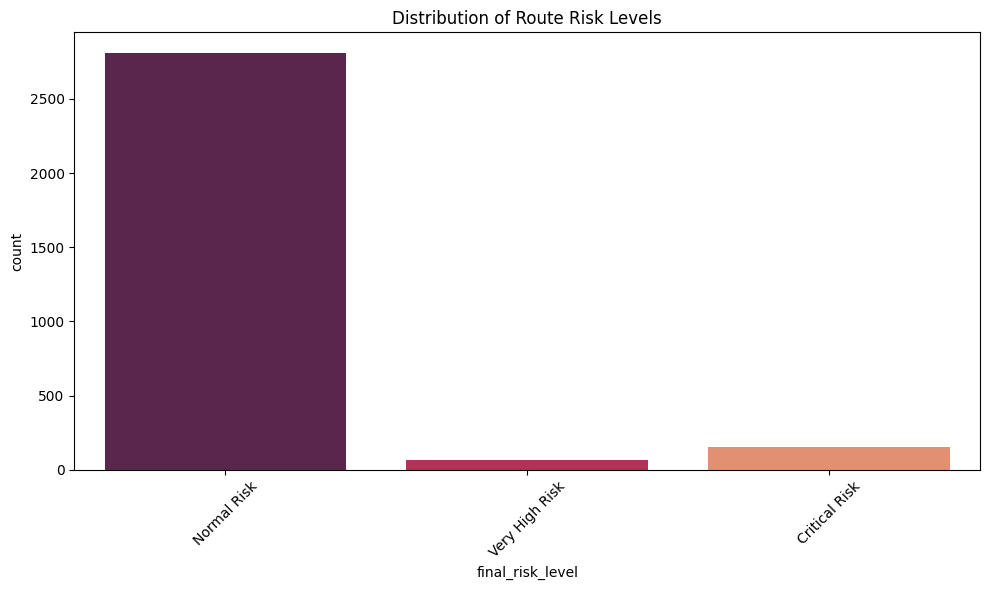

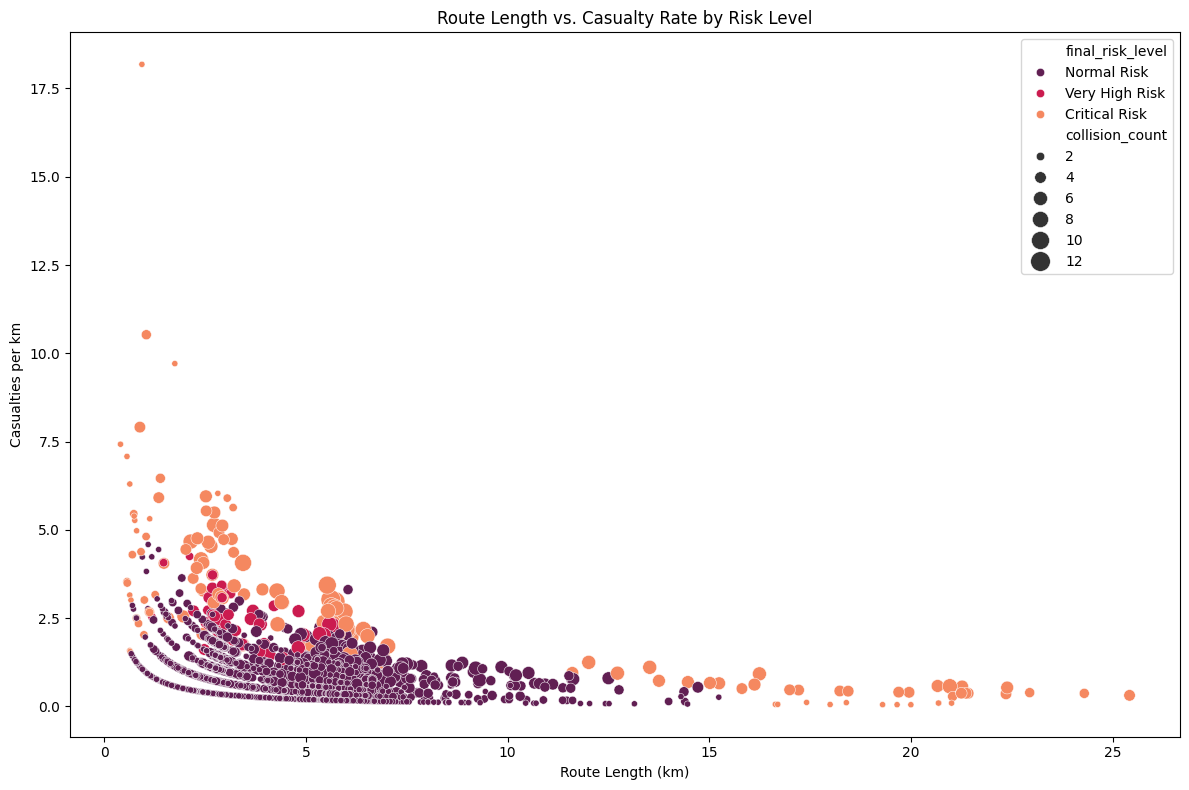

In [146]:
# Risk level distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='final_risk_level', data=df, palette='rocket')
plt.title('Distribution of Route Risk Levels')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('risk_level_distribution.png')

# Length vs Risk scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(x='length_km', y='casualty_count_per_km', 
                hue='final_risk_level', size='collision_count',
                sizes=(20, 200), data=df, palette='rocket')
plt.title('Route Length vs. Casualty Rate by Risk Level')
plt.xlabel('Route Length (km)')
plt.ylabel('Casualties per km')
plt.tight_layout()
plt.savefig('length_vs_risk.png')

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

# Example placeholder DataFrame (to be replaced with real one)
# df = pd.read_csv("your_input.csv")

# ---- Configuration ----
features = [
    'length_km',
    'collision_count',
    'casualty_count',
    'collision_count_per_km',
    'casualty_count_per_km',
    'poisson_risk_ratio_collision_count'
]
# df = df[(df['casualty_type'] == 0) | (df['casualty_type'] == 1)]
# ---- Preprocessing ----
X = df[features].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---- Clustering ----
kmeans = KMeans(n_clusters=5, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# Optional: DBSCAN and Hierarchical
df['dbscan_cluster'] = DBSCAN(eps=1.0, min_samples=5).fit_predict(X_scaled)
df['hierarchical_cluster'] = AgglomerativeClustering(n_clusters=5).fit_predict(X_scaled)

# ---- PCA for Visualization ----
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['pca_1'], df['pca_2'] = X_pca[:, 0], X_pca[:, 1]

# ---- Analyze Cluster Stats ----
cluster_stats = df.groupby('kmeans_cluster')[features].mean().sort_values('casualty_count_per_km', ascending=False)
ranked_clusters = cluster_stats.index.tolist()

# ---- Map Clusters to Risk Categories ----
risk_mapping = {
    ranked_clusters[0]: "Very High Risk",
    ranked_clusters[1]: "High Risk",
    ranked_clusters[2]: "Moderate Risk",
    ranked_clusters[3]: "Low Risk",
    ranked_clusters[4]: "Minimal Risk"
}
df["risk_category"] = df["kmeans_cluster"].map(risk_mapping)

# ---- Anomaly Detection ----
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = iso_forest.fit_predict(X_scaled)
df['is_anomaly'] = df['anomaly'] == -1

# ---- Final Risk Level ----
df["final_risk_level"] = df.apply(
    lambda row: "Critical Risk" if row['is_anomaly'] else row['risk_category'],
    axis=1
)

# ---- Final Review Table ----
final_review_routes = df[df['final_risk_level'].isin(['Critical Risk', 'Very High Risk'])]\
    .sort_values(by=['final_risk_level', 'casualty_count_per_km'], ascending=[False, False])\
    .head(30)

# ---- Visualizations ----

# PCA Cluster Scatter
plt.figure(figsize=(12, 8))
sns.scatterplot(x='pca_1', y='pca_2', hue='risk_category', data=df, s=50)
plt.title('Route Risk Clusters (PCA Visualization)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

# Risk Level Distribution
plt.figure(figsize=(10, 6))
risk_order = ["Minimal Risk", "Low Risk", "Moderate Risk", "High Risk", "Very High Risk", "Critical Risk"]
sns.countplot(x='final_risk_level', data=df, order=risk_order)
plt.title('Distribution of Route Risk Levels')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Length vs. Casualty per km Scatter
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='length_km', y='casualty_count_per_km',
    hue='final_risk_level', size='collision_count',
    sizes=(20, 200), data=df
)
plt.title('Route Length vs. Casualty Rate by Risk Level')
plt.xlabel('Route Length (km)')
plt.ylabel('Casualties per km')
plt.tight_layout()
plt.show()

# ---- Display Top Routes ----
display(name="Top 30 Routes for Manual Review", dataframe=final_review_routes[[
    'route_id', 'school_name', 'borough', 'length_km',
    'collision_count', 'casualty_count',
    'collision_count_per_km', 'casualty_count_per_km',
    'risk_category', 'is_anomaly', 'final_risk_level'
]])


KeyError: 'casualty_type'

In [152]:
pca = PCA(n_components=2)
pca.fit(X_scaled)
components = pd.DataFrame(pca.components_, columns=features, index=["PC1", "PC2"])
print(components.T)

                                         PC1       PC2
length_km                          -0.079269  0.749277
collision_count                     0.408410  0.396374
casualty_count                      0.401485  0.413121
collision_count_per_km              0.488280 -0.216150
casualty_count_per_km               0.434617 -0.131764
poisson_risk_ratio_collision_count  0.488280 -0.216150
